# Loading Time Model Training

Train a regression model for `loading_time_min` using featured data after outlier handling.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import joblib

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None



In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
INTERIM_DATA_DIR = PROJECT_ROOT / 'data' / 'interim'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

source_path = INTERIM_DATA_DIR / 'vw_timestamp_dashboard_featured_no_outlier.csv'
df = pd.read_csv(source_path)
df.shape

(7375, 57)

In [3]:
target_col = 'loading_time_min'

drop_cols = [
    'wait_call_min',
    'prepare_loading_min',
    'loading_time_min',
    'close_job_min',
    'total_time_min',
    'OperatorCarConfirm',
    'CarConfirm',
    'FirstPostPallet',
    'LastPostPallet',
    'PostingTime',
]

# Set features manually (edit this list directly)
manual_features = [
    'CarType',
    'PostLocationName',
    'CPACTileSapAmount',
    'PRESTIGETileSapAmount',
    'NEUSTILETileSapAmount',
    'CPACFittingSapAmount',
    'PRESTIGEFittingSapAmount',
    'NEUSTILEFittingSapAmount',
    'DURAFittingSapAmount',
    'ACCESSORIESSapAmount',
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'week_of_month',
    'shift',
    'active_queue_before',
    'active_queue_before_same_location',
    'has_tile',
    'has_fitting',
    'has_accessories',
    'product_group_count',
    'total_sap_amount',
    'truck_seq_no',
    'pick_list_type',
]

df_model = df.dropna(subset=[target_col]).copy()
y = df_model[target_col]

if manual_features:
    X = df_model[manual_features].copy()
else:
    X = df_model.drop(columns=drop_cols, errors='ignore')
feature_cols = X.columns.tolist()

numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train rows: {len(X_train):,}')
print(f'Test rows:  {len(X_test):,}')
print(f'Features used: {len(feature_cols)}')
print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')



Train rows: 5,900
Test rows:  1,475
Features used: 25
Numeric features: 21
Categorical features: 4
Numeric features: ['CPACTileSapAmount', 'PRESTIGETileSapAmount', 'NEUSTILETileSapAmount', 'CPACFittingSapAmount', 'PRESTIGEFittingSapAmount', 'NEUSTILEFittingSapAmount', 'DURAFittingSapAmount', 'ACCESSORIESSapAmount', 'hour', 'day_of_week', 'is_weekend', 'month', 'week_of_month', 'active_queue_before', 'active_queue_before_same_location', 'has_tile', 'has_fitting', 'has_accessories', 'product_group_count', 'total_sap_amount', 'truck_seq_no']
Categorical features: ['CarType', 'PostLocationName', 'shift', 'pick_list_type']


In [4]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# Priority order requested: GradientBoosting -> RandomForest -> XGBoost -> LightGBM -> CatBoost
model_spaces = {
    'gradient_boosting': {
        'estimator': GradientBoostingRegressor(random_state=42),
        'param_distributions': {
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__max_depth': [2, 3, 4, 6],
            'model__min_samples_leaf': [1, 2, 4, 8],
            'model__min_samples_split': [2, 5, 10, 20],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__max_features': ['sqrt', 0.8, None],
        },
        'n_iter': 15,
    },
    'random_forest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=1),
        'param_distributions': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [8, 12, 16, None],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 0.8],
            'model__min_samples_split': [2, 5, 10],
        },
        'n_iter': 15,
    },
}

if XGBRegressor is not None:
    model_spaces['xgboost'] = {
        'estimator': XGBRegressor(
            random_state=42,
            n_jobs=-1,
            objective='reg:squarederror',
            tree_method='hist',
        ),
        'param_distributions': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [4, 6, 8],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
            'model__min_child_weight': [1, 3, 5],
        },
        'n_iter': 15,
    }
else:
    print('Skip xgboost: package not installed')

if LGBMRegressor is not None:
    model_spaces['lightgbm'] = {
        'estimator': LGBMRegressor(random_state=42, n_jobs=1, verbose=-1),
        'param_distributions': {
            'model__n_estimators': [100, 200, 300],
            'model__num_leaves': [15, 31, 63],
            'model__max_depth': [-1, 6, 10],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
            'model__min_child_samples': [10, 20, 40],
        },
        'n_iter': 15,
    }
else:
    print('Skip lightgbm: package not installed')

if CatBoostRegressor is not None:
    model_spaces['catboost'] = {
        'estimator': CatBoostRegressor(
            random_seed=42,
            thread_count=1,
            verbose=0,
            allow_writing_files=False,
        ),
        'param_distributions': {
            'model__iterations': [200, 400, 600],
            'model__depth': [4, 6, 8],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__l2_leaf_reg': [1, 3, 5, 7],
            'model__subsample': [0.7, 0.85, 1.0],
        },
        'n_iter': 15,
    }
else:
    print('Skip catboost: package not installed')

cv = KFold(n_splits=3, shuffle=True, random_state=42)
search_rows = []
trained_models = {}

for model_name, config in model_spaces.items():
    print(f'Tuning: {model_name}')
    candidate_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', config['estimator']),
    ])

    search = RandomizedSearchCV(
        estimator=candidate_pipe,
        param_distributions=config['param_distributions'],
        n_iter=config['n_iter'],
        scoring='neg_mean_absolute_error',
        cv=cv,
        refit=True,
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_pipe = search.best_estimator_
    pred_test = best_pipe.predict(X_test)

    search_rows.append({
        'model': model_name,
        'cv_MAE': -search.best_score_,
        'test_MAE': mean_absolute_error(y_test, pred_test),
        'test_RMSE': float(np.sqrt(mean_squared_error(y_test, pred_test))),
        'test_R2': r2_score(y_test, pred_test),
        'best_params': search.best_params_,
    })
    trained_models[model_name] = {
        'pipe': best_pipe,
        'pred': pred_test,
    }

if not search_rows:
    raise RuntimeError('No model was trained. Please install at least one model package or keep sklearn models enabled.')

tuning_result = pd.DataFrame(search_rows).sort_values('test_MAE').reset_index(drop=True)
best_model_name = tuning_result.loc[0, 'model']
pipe = trained_models[best_model_name]['pipe']
pred = trained_models[best_model_name]['pred']

print(f'Best model on test MAE: {best_model_name}')

result = tuning_result.copy()

result


Tuning: gradient_boosting
Tuning: random_forest
Tuning: xgboost
Tuning: lightgbm


d:\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Tuning: catboost
Best model on test MAE: lightgbm


,model,cv_MAE,test_MAE,test_RMSE,test_R2,best_params
0,lightgbm,9.607752,9.640077,13.190160,0.532118,"{'model__subsample': 1.0, 'model__num_leaves':..."
1,catboost,9.591367,9.640798,13.062010,0.541165,"{'model__subsample': 1.0, 'model__learning_rat..."
2,xgboost,9.675281,9.748044,13.198366,0.531535,"{'model__subsample': 0.85, 'model__n_estimator..."
3,gradient_boosting,9.667066,9.760025,13.273080,0.526216,"{'model__subsample': 1.0, 'model__n_estimators..."
4,random_forest,9.838927,9.843153,13.213071,0.530491,"{'model__n_estimators': 100, 'model__min_sampl..."


## Model Comparison

C:\Users\phanudes\AppData\Local\Temp\ipykernel_5712\10072718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x='test_MAE', y='model', ax=axes[0], palette='Blues_r')
C:\Users\phanudes\AppData\Local\Temp\ipykernel_5712\10072718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x='test_RMSE', y='model', ax=axes[1], palette='Greens_r')
C:\Users\phanudes\AppData\Local\Temp\ipykernel_5712\10072718.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x='test_R2', y='model', ax=axes[2], palett

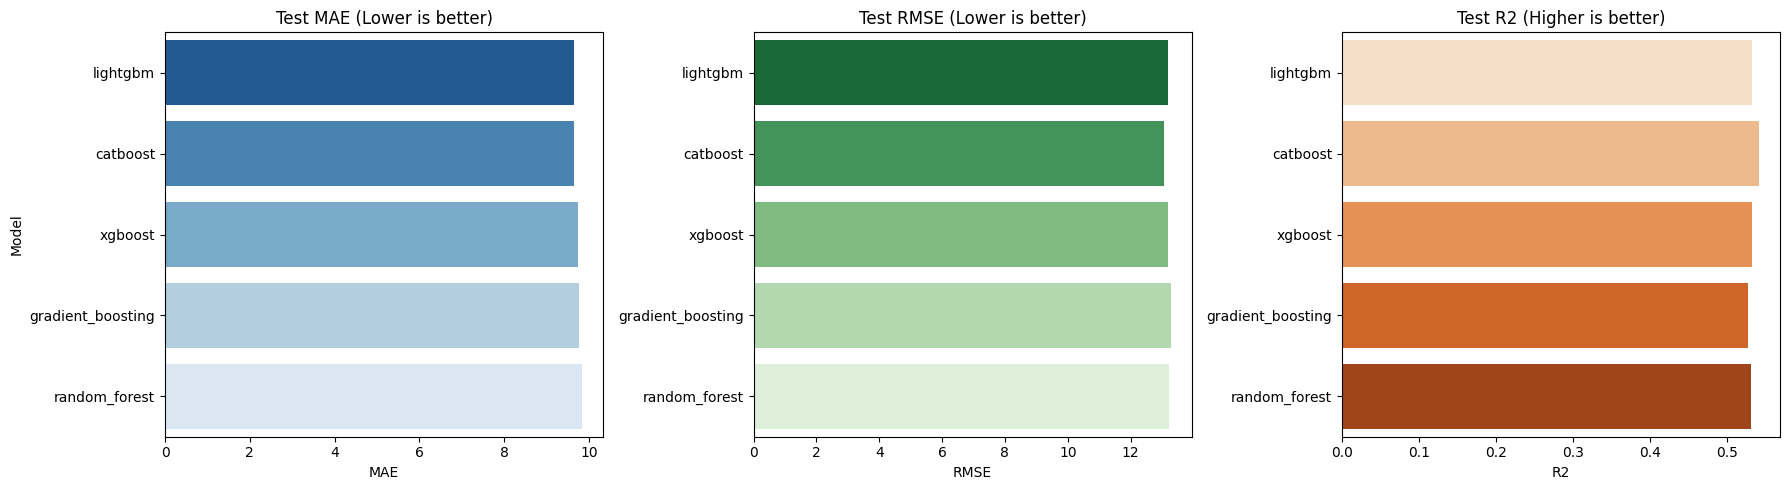

In [5]:
compare_df = result.copy().sort_values('test_MAE')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=compare_df, x='test_MAE', y='model', ax=axes[0], palette='Blues_r')
axes[0].set_title('Test MAE (Lower is better)')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Model')

sns.barplot(data=compare_df, x='test_RMSE', y='model', ax=axes[1], palette='Greens_r')
axes[1].set_title('Test RMSE (Lower is better)')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')

sns.barplot(data=compare_df, x='test_R2', y='model', ax=axes[2], palette='Oranges')
axes[2].set_title('Test R2 (Higher is better)')
axes[2].set_xlabel('R2')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## Model Diagnostic Plots

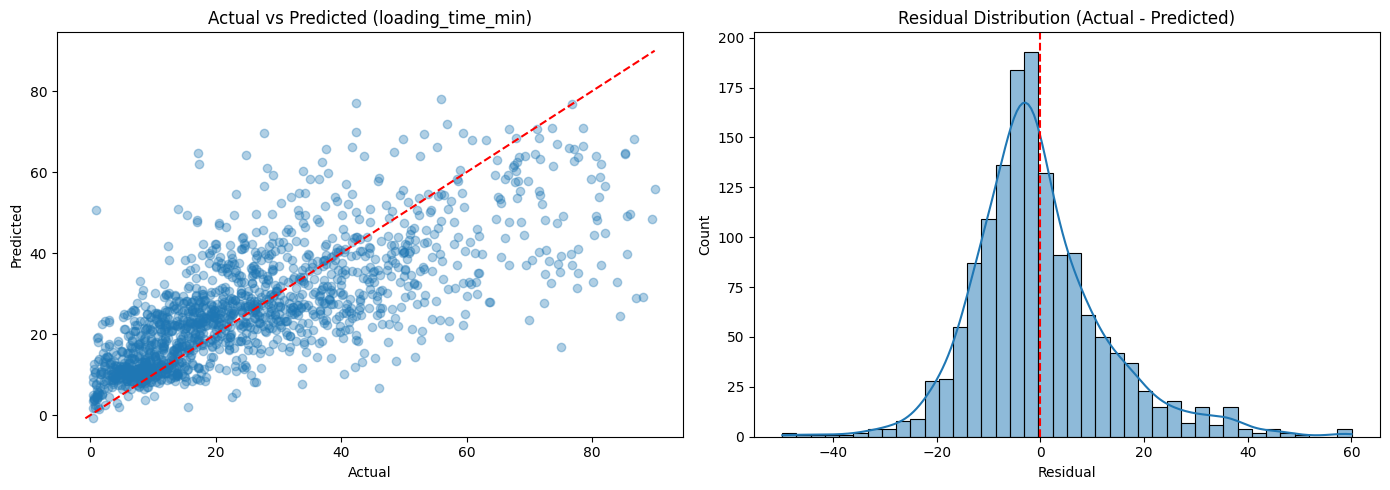

In [6]:
residual = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred, alpha=0.35)
diag_min = min(float(y_test.min()), float(pred.min()))
diag_max = max(float(y_test.max()), float(pred.max()))
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted (loading_time_min)')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

sns.histplot(residual, bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution (Actual - Predicted)')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()


## Important Features (Permutation Importance)

d:\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


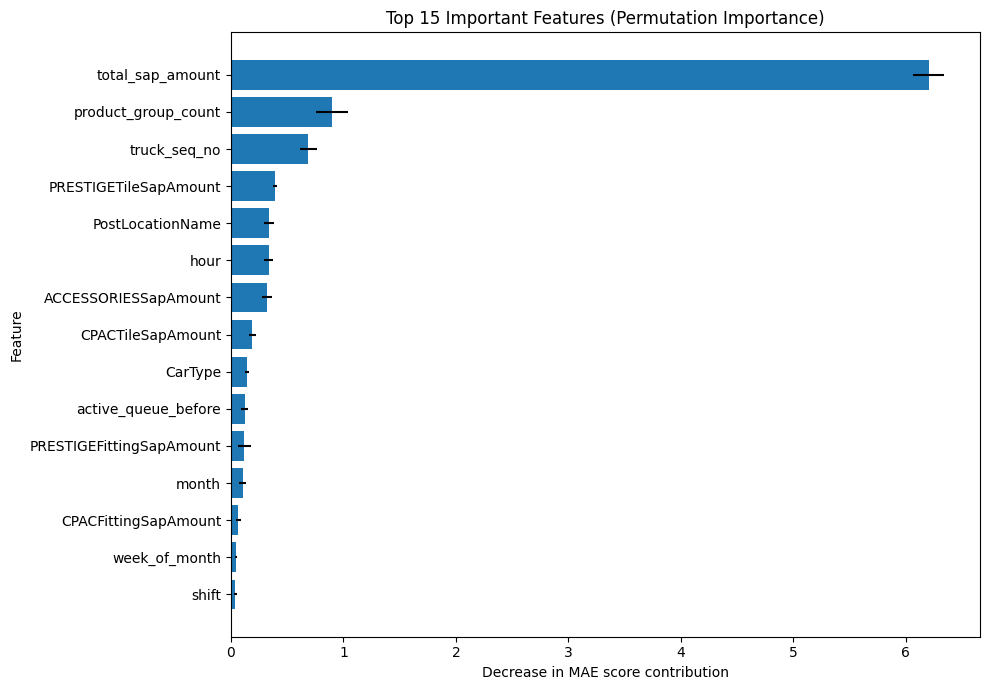

,feature,importance_mean,importance_std
22,total_sap_amount,6.202899,0.139290
21,product_group_count,0.901484,0.141725
23,truck_seq_no,0.686361,0.074873
3,PRESTIGETileSapAmount,0.390195,0.017978
1,PostLocationName,0.341855,0.043316
10,hour,0.337386,0.041007
9,ACCESSORIESSapAmount,0.320402,0.041787
2,CPACTileSapAmount,0.190180,0.031708
0,CarType,0.142366,0.014836
16,active_queue_before,0.123282,0.030545


In [7]:
perm = permutation_importance(
    pipe,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

top_n = 15
top_importance = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_importance['feature'], top_importance['importance_mean'], xerr=top_importance['importance_std'])
plt.title(f'Top {top_n} Important Features (Permutation Importance)')
plt.xlabel('Decrease in MAE score contribution')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(20)


In [8]:
model_path = MODEL_DIR / f'loading_time_best_{best_model_name}.joblib'
joblib.dump(pipe, model_path)

report_path = MODEL_DIR / 'loading_time_model_search_result.csv'
result.to_csv(report_path, index=False)

print(f'Saved best model to: {model_path}')
print(f'Saved search report to: {report_path}')

Saved best model to: D:\ML\models\loading_time_best_lightgbm.joblib
Saved search report to: D:\ML\models\loading_time_model_search_result.csv
